# One Script, Two Engines

Running the same model under PathSim and under FastSim, without changing it.

## The idea

FastSim mirrors PathSim's API: the same block names, the same constructor arguments, the same `Simulation` and `Connection`, the same `Scope.read()`. A model written against one runs against the other.

```python
import pathsim as engine    # or:  import fastsim as engine
```

That is the whole switch. This notebook builds one model, runs it under both, and checks that they agree — and where they do not, says why.

## The Model

A DC motor under PI speed control — a plant, a controller and feedback, which is enough to exercise algebraic ordering as well as integration:

$$J\dot{\omega} = K_t i - b\omega, \qquad u = K_p e + K_i\!\int\! e\,dt, \qquad e = \omega_{\text{ref}} - \omega$$

In [1]:
import time

import numpy as np
import matplotlib.pyplot as plt

# Apply the FastSim docs matplotlib style
plt.style.use('../fastsim_docs.mplstyle')

import fastsim
import pathsim

print(f"pathsim {pathsim.__version__}")
print(f"fastsim {fastsim.__version__}")

pathsim 0.23.0
fastsim 0.25.0


## System Parameters

In [2]:
J, b, K_t = 0.01, 0.02, 0.05     # inertia, friction, torque constant
K_p, K_i = 0.4, 2.5              # controller gains
OMEGA_REF = 100.0                # setpoint [rad/s]

DT, T_END = 1e-3, 2.0

## Block Diagram

The factory takes the engine module and builds the model out of it. Nothing inside depends on which one it is.

In [3]:
def build(engine):
    B = engine.blocks

    ref = B.Source(lambda t: OMEGA_REF)
    err = B.Adder("+-")
    kp = B.Amplifier(K_p)
    ki = B.Amplifier(K_i)
    integ = B.Integrator()
    u = B.Adder("++")
    motor = B.ODE(lambda x, u, t: (K_t * u[0] - b * x) / J, initial_value=0.0)
    sco = B.Scope(labels=["omega"], sampling_period=DT)

    sim = engine.Simulation(
        blocks=[ref, err, kp, ki, integ, u, motor, sco],
        connections=[
            engine.Connection(ref, err[0]),
            engine.Connection(motor, err[1], sco),
            engine.Connection(err, kp, integ),
            engine.Connection(integ, ki),
            engine.Connection(kp, u[0]),
            engine.Connection(ki, u[1]),
            engine.Connection(u, motor),
        ],
        Solver=engine.solvers.RK4,
        dt=DT,
        log=False,
    )
    return sim, sco

## Simulation

Same call, twice.

In [4]:
def run(engine):
    sim, sco = build(engine)
    t0 = time.perf_counter()
    sim.run(T_END, reset=True, adaptive=False)
    wall = time.perf_counter() - t0
    t, [omega] = sco.read()
    return np.asarray(t), np.asarray(omega), wall

t_ps, w_ps, wall_ps = run(pathsim)
t_fs, w_fs, wall_fs = run(fastsim)

print(f"pathsim: {len(t_ps)} samples in {wall_ps * 1e3:7.1f} ms")
print(f"fastsim: {len(t_fs)} samples in {wall_fs * 1e3:7.1f} ms")
print(f"speedup: {wall_ps / wall_fs:.1f}x")

pathsim: 2001 samples in   222.2 ms
fastsim: 2001 samples in     1.8 ms
speedup: 121.1x


## Results

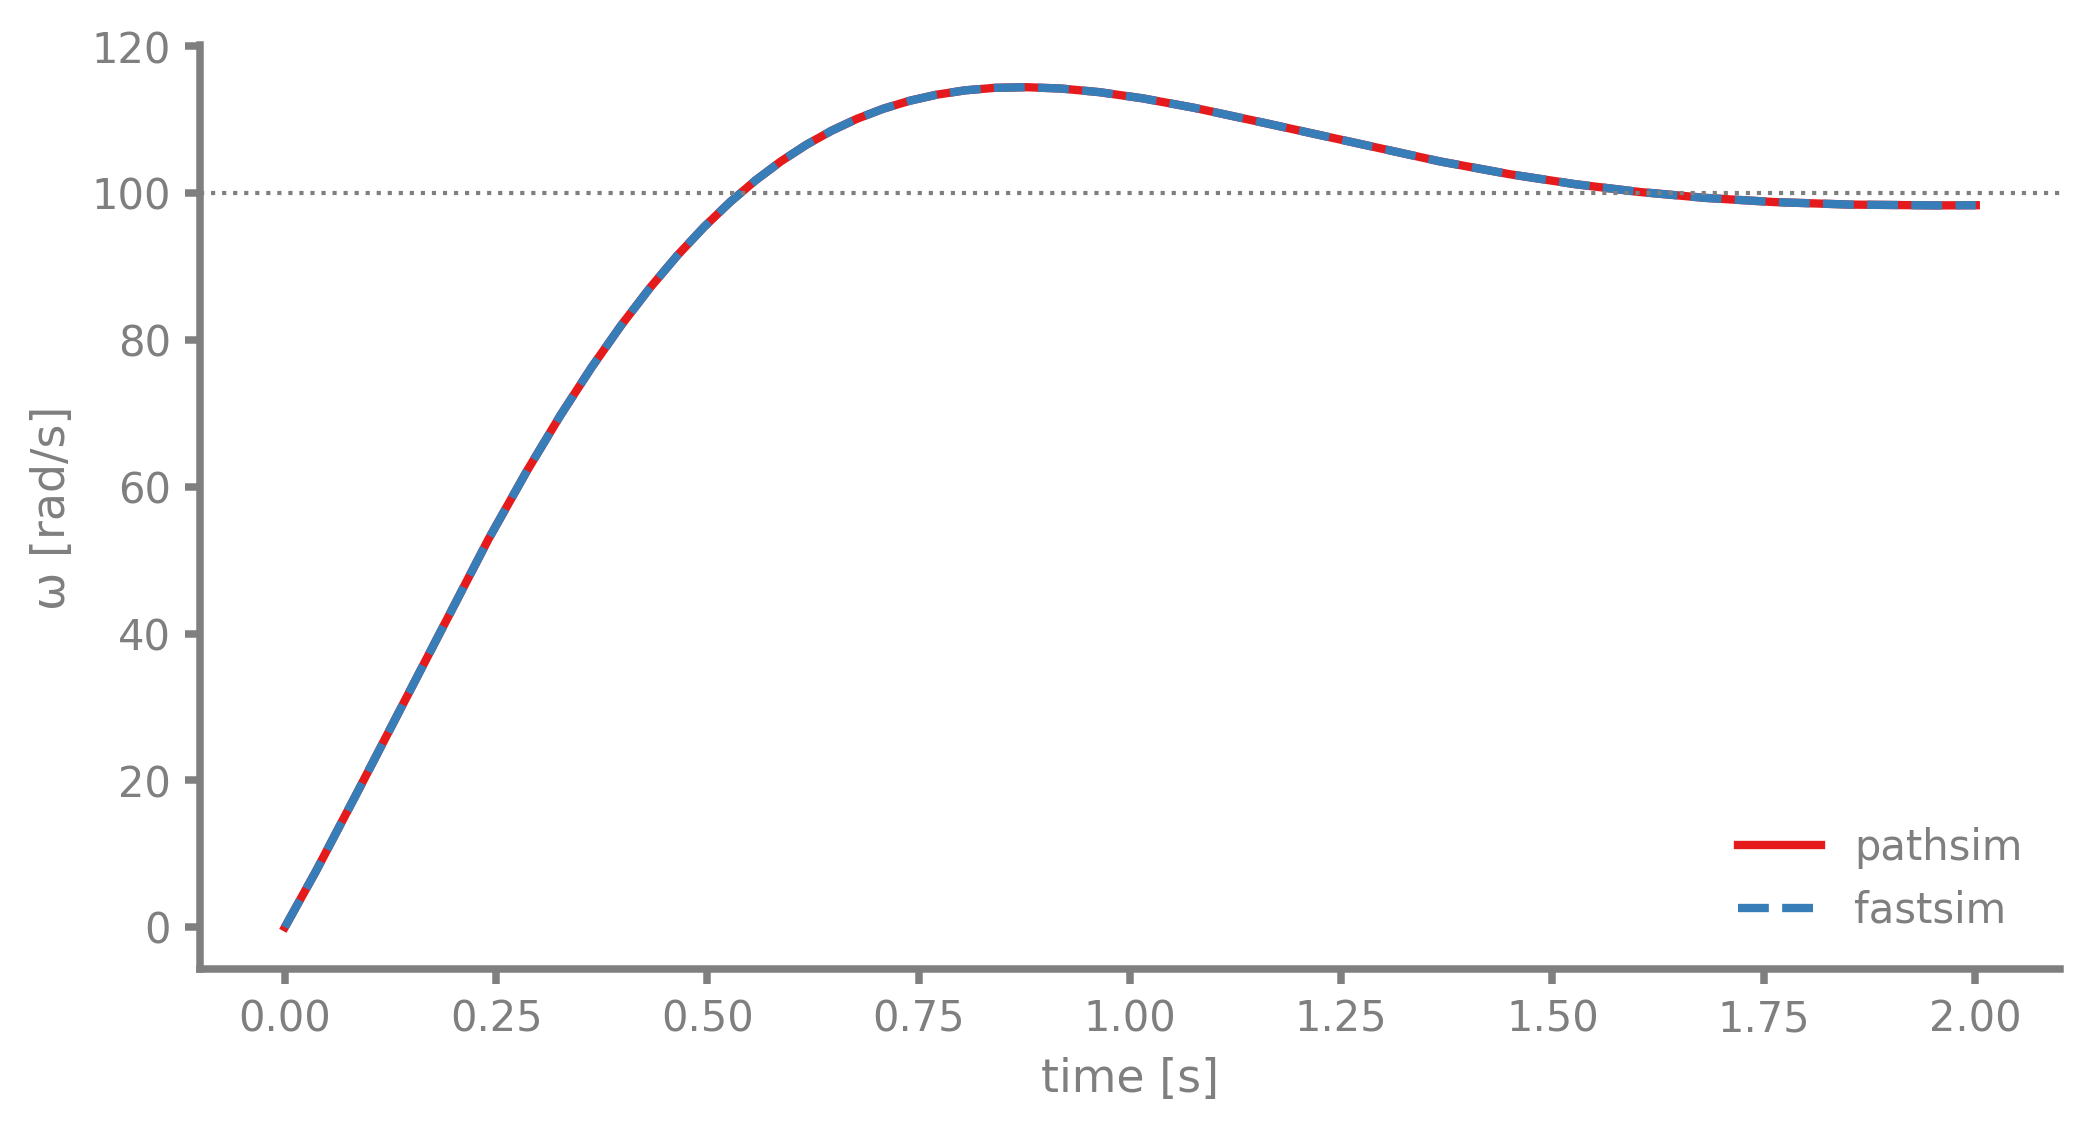

In [5]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t_ps, w_ps, label="pathsim")
ax.plot(t_fs, w_fs, "--", label="fastsim")
ax.axhline(OMEGA_REF, color="#7F7F7F", lw=1, ls=":")
ax.set_xlabel("time [s]")
ax.set_ylabel("ω [rad/s]")
ax.legend()
plt.show()

## Verification

Both engines record on the same fixed grid, so the trajectories compare sample for sample — no interpolation to blur the answer.

In [6]:
assert np.allclose(t_ps, t_fs, rtol=0, atol=1e-12), "the two runs did not sample the same times"

err = np.abs(w_ps - w_fs)
print(f"worst |pathsim - fastsim| : {err.max():.3e} rad/s")
print(f"relative to the setpoint  : {err.max() / OMEGA_REF:.3e}")

worst |pathsim - fastsim| : 0.000e+00 rad/s
relative to the setpoint  : 0.000e+00


Zero — the two engines produce the same doubles here, not merely close ones.

That is not guaranteed in general: two independent implementations of the same recurrence are free to associate their arithmetic differently, and a model with more algebra in it will usually land a few ULP apart instead. What the check is for is the distinction between that and a difference in *modelling*, which is the kind that grows.

## Where They Do Differ

Agreement this close is the normal case, not a universal one. Three things move a model off it, none of them a defect:

- **Stochastic sources.** `WhiteNoise`, `PinkNoise` and the phase-noise sources draw from engine-specific PRNG streams. Their statistics match; their sample paths do not.
- **Adaptive stepping across a non-smooth point.** With `adaptive=True`, the two step controllers can take different step sequences around a saturation or an event, and then land on slightly different trajectories. Under a fixed step the same models agree to rounding.
- **Event location.** An event resolved at a slightly different instant moves everything after it — most visibly for contact events, where a small shift in time is a large shift in state.

The fixed-step run above avoids all three, which is what makes it a clean comparison of the engines rather than of their step controllers.

## Mixing Blocks

Models do not have to be all-or-nothing. `port` turns a PathSim block into a FastSim one — accelerated where its behaviour can be expressed natively, wrapped otherwise. Anything passed in `blocks` is ported automatically; a block you want to *wire* has to be ported first, since `Connection` takes FastSim blocks.

In [7]:
from fastsim import port

mixed_src = port(pathsim.blocks.Source(lambda t: OMEGA_REF))  # a PathSim block ...
integ = fastsim.blocks.Integrator()                            # ... next to a FastSim one
sco = fastsim.blocks.Scope(labels=["x"], sampling_period=DT)

sim = fastsim.Simulation(
    blocks=[mixed_src, integ, sco],
    connections=[fastsim.Connection(mixed_src, integ), fastsim.Connection(integ, sco)],
    Solver=fastsim.solvers.RK4, dt=DT, log=False,
)
sim.run(1.0, reset=True, adaptive=False)

t_mix, [x_mix] = sco.read()
print(f"x(1) = {x_mix[-1]:.9f}   (a constant {OMEGA_REF} integrated over 1 s)")

x(1) = 100.000000000   (a constant 100.0 integrated over 1 s)
